# Stable Video Diffusion with Perceptual Trajectory Guidance

This notebook implements perceptual trajectory smoothing and ensemble techniques for Stable Video Diffusion (SVD).

In [1]:
# ==========================================
# CELL 1: Configuration and Imports
# ==========================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from diffusers import StableVideoDiffusionPipeline, AutoencoderKL
from diffusers.utils import export_to_gif
from torchvision.transforms import GaussianBlur
import matplotlib.pyplot as plt

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float16,
    "num_frames": 14,
    "fps": 2,
    "height": 320,
    "width": 576,
    "run_standard_psg": True,
    "run_strong_straightening": False,
    "run_kernel_regression": True,
    "kernel_degrees": [2, 3, 4, 5],
    "run_mpes_ensemble": True,
    "ensemble_paths": 3,
    "save_dir": "./experiment-results"
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)
for sub in ["videos", "trajectories", "plots"]:
    os.makedirs(os.path.join(CONFIG["save_dir"], sub), exist_ok=True)

# Read HF token
with open("hf-access-token.txt", "r") as f:
    hf_token = f.read().strip()

print("Setup Complete. Config initialized.")

c:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup Complete. Config initialized.


In [2]:
# ==========================================
# CELL 2: Lightweight V1 Perceptual Space
# ==========================================

class V1PerceptualSpace(nn.Module):
    def __init__(self):
        super().__init__()
        self.filters = nn.Conv2d(3, 12, kernel_size=15, padding=7, bias=False, groups=3)
        self.filters.weight.requires_grad = False
        nn.init.normal_(self.filters.weight, std=0.1)
        self.retina_blur = GaussianBlur(kernel_size=5, sigma=1.0)
        
    def forward(self, x):
        blurred = self.retina_blur(x)
        retina_out = x - blurred
        v1_response = F.relu(self.filters(retina_out))
        return F.adaptive_avg_pool2d(v1_response, (1, 1)).view(x.size(0), -1)

v1_space = V1PerceptualSpace().to(CONFIG["device"], CONFIG["dtype"])

In [3]:
# ==========================================
# CELL 3: Core Trajectory & Constraint Methods (PRECISION FIXED)
# ==========================================

def calculate_curvature_loss(v1_features):
    displacements = v1_features[1:] - v1_features[:-1]
    disp_norm = F.normalize(displacements, p=2, dim=1)
    cos_sim = torch.sum(disp_norm[:-1] * disp_norm[1:], dim=1)
    cos_sim = torch.clamp(cos_sim, -1.0 + 1e-7, 1.0 - 1e-7)
    curvature = torch.acos(cos_sim)
    return curvature.mean()

def apply_strong_straightening(latent_seq):
    N = latent_seq.shape[0]
    start_frame = latent_seq[0]
    end_frame = latent_seq[-1]
    linearized = torch.zeros_like(latent_seq)
    for i in range(N):
        alpha = i / (N - 1)
        linearized[i] = (1 - alpha) * start_frame + alpha * end_frame
    return linearized

def kernel_trajectory_regression(latent_seq, parameters=3):
    N = latent_seq.shape[0]
    
    # FIX: Force 't' and 'A' to use float32 for numerical stability
    t = torch.linspace(0, 1, N, device=latent_seq.device, dtype=torch.float32).unsqueeze(1)
    A = torch.cat([t**i for i in range(parameters)], dim=1)
    
    # FIX: Temporarily cast the latent sequence to float32
    flat_seq = latent_seq.reshape(N, -1).to(torch.float32)
    
    # Matrix inversion is now safely performed in float32
    A_T = A.t()
    pseudo_inv = torch.inverse(A_T @ A) @ A_T
    coeffs = pseudo_inv @ flat_seq
    smoothed_flat = A @ coeffs
    
    # FIX: Cast the result back to fp16 (latent_seq.dtype) before returning
    return smoothed_flat.reshape(latent_seq.shape).to(latent_seq.dtype)

In [4]:
# ==========================================
# CELL 4: Pipeline Hook for Inference
# ==========================================

def perceptual_guidance_step_callback(pipeline, step_index, timestep, callback_kwargs):
    latents = callback_kwargs["latents"]
    seq = latents[0].permute(1, 0, 2, 3)
    
    if CONFIG["run_strong_straightening"] and step_index % 5 == 0:
        seq = apply_strong_straightening(seq)
        
    if CONFIG["run_kernel_regression"] and step_index % 5 == 0:
        seq = kernel_trajectory_regression(seq, parameters=3)
        
    latents[0] = seq.permute(1, 0, 2, 3)
    callback_kwargs["latents"] = latents
    return callback_kwargs

In [5]:
# ==========================================
# CELL 5: The Two-Step Text-to-Video Pipeline (With A/B Comparison)
# ==========================================
import gc
import torch
from diffusers import StableDiffusionXLPipeline, StableVideoDiffusionPipeline
from diffusers.utils import export_to_gif

# Define your text prompt here - added "mid-stride" to force motion in the starting frame
TEXT_PROMPT = "Action shot, motion blur, a futuristic cyberpunk robot mid-stride walking down a neon-lit street, 8k resolution, photorealistic"

# ---------------------------------------------------------
# PHASE 1: TEXT TO IMAGE (SDXL)
# ---------------------------------------------------------
print("Phase 1: Loading SDXL...")

# 1. Nuke any lingering memory before we start
gc.collect()
torch.cuda.empty_cache()

t2i_pipeline = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)
# Offloads SDXL layers back to RAM immediately after they are used
t2i_pipeline.enable_model_cpu_offload()

print(f"Generating starting frame for prompt: '{TEXT_PROMPT}'")
generated_image = t2i_pipeline(
    prompt=TEXT_PROMPT,
    num_inference_steps=25,
    height=576, 
    width=1024
).images[0]

generated_image.save(f"{CONFIG['save_dir']}/starting_frame.png")
print("Starting frame generated and saved!")

# ---------------------------------------------------------
# THE MEMORY AIRLOCK (CRITICAL FOR RTX 4060)
# ---------------------------------------------------------
print("Purging SDXL from memory...")
del t2i_pipeline
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Resize the pristine SDXL image down to our safe SVD resolution
input_img_pil = generated_image.resize((CONFIG["width"], CONFIG["height"]))

# ---------------------------------------------------------
# PHASE 2: IMAGE TO VIDEO (SVD with Perceptual Straightening)
# ---------------------------------------------------------
print("Phase 2: Loading Stable Video Diffusion...")

svd_pipeline = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid",
    torch_dtype=CONFIG["dtype"],
    variant="fp16",
    use_safetensors=True,
    token=hf_token
)

# Maximum VRAM conservation for the video generation
svd_pipeline.enable_sequential_cpu_offload()

try:
    svd_pipeline.enable_xformers_memory_efficient_attention()
except Exception:
    pass # Falls back to PyTorch native SDPA

# --- GENERATION 1: BASELINE (NO STRAIGHTENING) ---
print("Generating Base Video (No Guidance)...")
base_out = svd_pipeline(
    input_img_pil,
    decode_chunk_size=1,
    generator=torch.manual_seed(42),
    motion_bucket_id=127,
    noise_aug_strength=0.02,
    num_frames=CONFIG["num_frames"]
).frames[0]

export_to_gif(base_out, f"{CONFIG['save_dir']}/videos/base_video.gif")
print("Base video saved!")



Phase 1: Loading SDXL...


Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.17it/s]


Generating starting frame for prompt: 'Action shot, motion blur, a futuristic cyberpunk robot mid-stride walking down a neon-lit street, 8k resolution, photorealistic'


100%|██████████| 25/25 [00:21<00:00,  1.18it/s]
c:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\.venv\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Starting frame generated and saved!
Purging SDXL from memory...
Phase 2: Loading Stable Video Diffusion...


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  6.18it/s]


Generating Base Video (No Guidance)...


100%|██████████| 25/25 [04:06<00:00,  9.87s/it]


Base video saved!


In [6]:
# --- GENERATION 2: GUIDED (PERCEPTUAL STRAIGHTENING) ---
print("Generating Guided Video with Perceptual Straightening...")
guided_out = svd_pipeline(
    input_img_pil,
    decode_chunk_size=1,
    generator=torch.manual_seed(42), # Exact same seed to guarantee same initial noise
    motion_bucket_id=127,            # Exact same motion bucket
    noise_aug_strength=0.02,
    callback_on_step_end=perceptual_guidance_step_callback, # <--- The intervention
    callback_on_step_end_tensor_inputs=["latents"],
    num_frames=CONFIG["num_frames"]
).frames[0]

export_to_gif(guided_out, f"{CONFIG['save_dir']}/videos/text_to_guided_video.gif")
print("Success! Both videos generated for comparison.")

Generating Guided Video with Perceptual Straightening...


100%|██████████| 25/25 [03:47<00:00,  9.08s/it]


Success! Both videos generated for comparison.


In [8]:
# ==========================================
# CELL 6: Multi-Path Ensemble Sampling (MPES)
# ==========================================
import numpy as np
import torch

def mpes_generation(image, paths=3):
    print(f"Running MPES with {paths} paths...")
    all_latents = []
    for i in range(paths):
        out = svd_pipeline(
            image,
            decode_chunk_size=1, 
            generator=torch.manual_seed(42 + i),
            output_type="latent",
            num_frames=CONFIG["num_frames"]
        ).frames
        all_latents.append(out)

    # Average in latent space
    avg_latents = sum(all_latents) / paths
    
    print("Decoding averaged latents...")
    decoded_frames = []
    for i in range(CONFIG["num_frames"]):
        # FIX: Select exactly index 'i' instead of slicing 'i:i+1'. 
        # This turns the 5D tensor into the 4D tensor [1, 4, H, W] the VAE expects.
        frame_latent = avg_latents[:, i, :, :, :]
        
        with torch.no_grad():
            frame_pixel = svd_pipeline.vae.decode(
                frame_latent / svd_pipeline.vae.config.scaling_factor,
                num_frames=1
            ).sample
            
        # Post-process tensor to PIL
        frame_pixel = (frame_pixel / 2 + 0.5).clamp(0, 1)
        frame_pixel = frame_pixel.cpu().permute(0, 2, 3, 1).float().numpy()
        from PIL import Image
        frame_pil = Image.fromarray((frame_pixel[0] * 255).astype(np.uint8))
        decoded_frames.append(frame_pil)
        
    return decoded_frames

if CONFIG["run_mpes_ensemble"]:
    mpes_out = mpes_generation(input_img_pil, paths=CONFIG["ensemble_paths"])
    export_to_gif(mpes_out, f"{CONFIG['save_dir']}/videos/mpes_video.gif")
    print("MPES video generated and saved!")

Running MPES with 3 paths...


100%|██████████| 25/25 [03:45<00:00,  9.03s/it]


Decoding averaged latents...
MPES video generated and saved!


Base Trajectory Curvature: 1.3066
Guided Trajectory Curvature: 1.1045


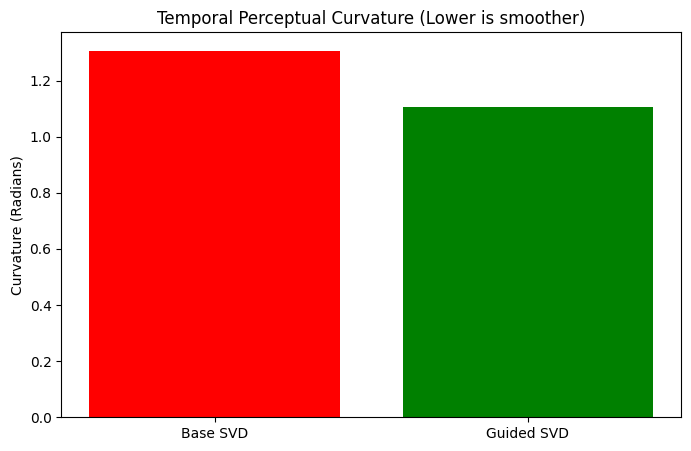

In [9]:
# ==========================================
# CELL 7: Evaluation Metrics & Plotting
# ==========================================

def compute_temporal_consistency_metric(video_frames_list):
    import torchvision.transforms as T
    transform = T.Compose([T.ToTensor(), T.Resize((128, 128))])

    tensors = torch.stack([transform(f) for f in video_frames_list]).to(
        CONFIG["device"], CONFIG["dtype"]
    )

    with torch.no_grad():
        v1_feats = v1_space(tensors)
        curvature = calculate_curvature_loss(v1_feats)
    return curvature.item()

base_curv = compute_temporal_consistency_metric(base_out)
guided_curv = compute_temporal_consistency_metric(guided_out)

print(f"Base Trajectory Curvature: {base_curv:.4f}")
print(f"Guided Trajectory Curvature: {guided_curv:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(['Base SVD', 'Guided SVD'], [base_curv, guided_curv], color=['red', 'green'])
plt.title('Temporal Perceptual Curvature (Lower is smoother)')
plt.ylabel('Curvature (Radians)')
plt.savefig(f"{CONFIG['save_dir']}/plots/curvature_comparison.png")
plt.show()

In [10]:
# ==========================================
# CELL 7: Kernel Regression Degree Experiment
# ==========================================
import os
import gc
import torch
from diffusers.utils import export_to_gif

# 1. Setup the dedicated subfolder
kernel_save_dir = os.path.join(CONFIG["save_dir"], "videos", "kernel_degrees")
os.makedirs(kernel_save_dir, exist_ok=True)
print(f"Saving regression experiments to: {kernel_save_dir}")

# 2. The Callback Factory
# This dynamically builds a callback function for the specific polynomial degree
def get_dynamic_regression_callback(degree):
    def dynamic_callback(pipe, step_index, timestep, callback_kwargs):
        latents = callback_kwargs["latents"]
        # Extract temporal sequence: [F, C, H, W]
        seq = latents[0].permute(1, 0, 2, 3) 
        
        # Apply the smoothing filter every 5 steps
        if step_index % 5 == 0:
            seq = kernel_trajectory_regression(seq, parameters=degree)
            
        latents[0] = seq.permute(1, 0, 2, 3)
        callback_kwargs["latents"] = latents
        return callback_kwargs
    return dynamic_callback

# 3. Run the Experiment Loop
degrees_to_test = [2, 3, 4, 5]

for deg in degrees_to_test:
    print(f"\n--- Generating Video with {deg}-Parameter Kernel Regression ---")
    
    # Optional: Brief explanation of what the math is doing
    if deg == 2:
        print("    (Degree 2 = Pure Linear Trajectory. Expected: Highly restricted motion)")
    elif deg == 3:
        print("    (Degree 3 = Quadratic Trajectory. Expected: Smooth acceleration/deceleration)")
    elif deg == 5:
        print("    (Degree 5 = Quartic Trajectory. Expected: Allows complex motion but filters micro-jitters)")

    # Generate the video
    deg_out = svd_pipeline(
        input_img_pil, # Uses the exact same starting frame from SDXL
        decode_chunk_size=1, # Mandatory VRAM protection
        generator=torch.manual_seed(42), # Lock seed for true A/B/C/D comparison
        motion_bucket_id=127,
        noise_aug_strength=0.02,
        callback_on_step_end=get_dynamic_regression_callback(deg),
        callback_on_step_end_tensor_inputs=["latents"],
        num_frames=CONFIG["num_frames"]
    ).frames[0]

    # Save the output
    save_path = os.path.join(kernel_save_dir, f"regression_degree_{deg}.gif")
    export_to_gif(deg_out, save_path)
    print(f"Saved: {save_path}")
    
    # 4. Mandatory VRAM Purge between runs
    # Even with sequential offload, intermediate tensors can build up in the cache
    del deg_out
    gc.collect()
    torch.cuda.empty_cache()

print("\nExperiment Complete! You can now compare the GIFs side-by-side.")

Saving regression experiments to: ./experiment-results\videos\kernel_degrees

--- Generating Video with 2-Parameter Kernel Regression ---
    (Degree 2 = Pure Linear Trajectory. Expected: Highly restricted motion)


100%|██████████| 25/25 [03:39<00:00,  8.79s/it]


Saved: ./experiment-results\videos\kernel_degrees\regression_degree_2.gif

--- Generating Video with 3-Parameter Kernel Regression ---
    (Degree 3 = Quadratic Trajectory. Expected: Smooth acceleration/deceleration)


100%|██████████| 25/25 [03:41<00:00,  8.86s/it]


Saved: ./experiment-results\videos\kernel_degrees\regression_degree_3.gif

--- Generating Video with 4-Parameter Kernel Regression ---


100%|██████████| 25/25 [03:42<00:00,  8.92s/it]


Saved: ./experiment-results\videos\kernel_degrees\regression_degree_4.gif

--- Generating Video with 5-Parameter Kernel Regression ---
    (Degree 5 = Quartic Trajectory. Expected: Allows complex motion but filters micro-jitters)


100%|██████████| 25/25 [03:43<00:00,  8.94s/it]


Saved: ./experiment-results\videos\kernel_degrees\regression_degree_5.gif

Experiment Complete! You can now compare the GIFs side-by-side.
